# MNIST: red neuronal densa

Este notebook estudia un problema de clasificación de imágenes sobre el conjunto de datos [MNIST](https://es.wikipedia.org/wiki/Base_de_datos_MNIST), formado por imágenes de dígitos escritos a mano del 0 al 9.

El objetivo del trabajo es entrenar y analizar redes neuronales completamente conectadas utilizando Keras y TensorFlow. A lo largo del notebook se estudian distintas decisiones de diseño, como el número de neuronas, las funciones de activación, la inicialización de pesos, los optimizadores, el número de épocas, el early stopping y las técnicas de regularización.

El análisis incluye el preprocesado de los datos, el entrenamiento de varios modelos, la comparación de resultados y la evaluación final sobre el conjunto de test.

In [4]:
from keras.datasets.mnist import load_data
import tensorflow as tf
import matplotlib.pyplot as plt

Tenemos la suerte de que el dataset MNIST, el que vamos a utilizar en esta actividad, está guardado en Keras, por lo que podemos utilizarlo sin necesidad de buscar el dataset de forma externa.

In [5]:
#mnist = tf.keras.datasets.fashion_mnist

Llamar a **load_data** en este dataset nos dará dos conjuntos de dos listas, estos serán los valores de entrenamiento y prueba para los gráficos que contienen los dígitos y sus etiquetas.

Nota: Aunque en esta actividad lo veis de esta forma, también lo vais a poder encontrar como 4 variables de esta forma: training_images, training_labels, test_images, test_labels = mnist.load_data()

In [6]:
(training_images, training_labels), (test_images, test_labels) = load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Antes de continuar vamos a dar un vistazo a nuestro dataset, para ello vamos a ver una imagen de entrenamiento y su etiqueta o clase.

5
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241   0 

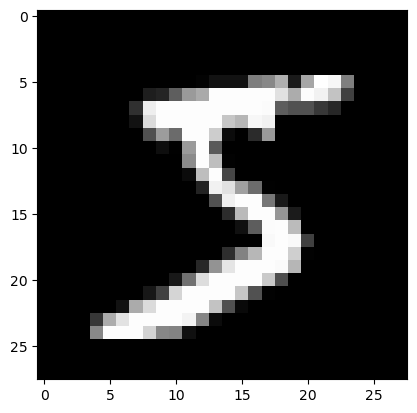

In [7]:
import numpy as np
np.set_printoptions(linewidth=200)
plt.imshow(training_images[0], cmap="gray") # recordad que siempre es preferible trabajar en blanco y negro
#
print(training_labels[0])
print(training_images[0])

## 1. Información sobre el dataset

Una vez tenemos los datos cargados en memoria, vamos a obtener información sobre los mismos.

**Pregunta 1.1** ¿Cuántas imágenes hay de *training* y de *test*? ¿Qué tamaño tienen las imágenes?

In [ ]:
print(f"Número de imágenes de entrenamiento: {training_images.shape[0]}")
print(f"Número de imágenes de test: {test_images.shape[0]}")
print(f"Tamaño de cada imagen: {training_images.shape[1:]}") 

Número de imágenes de entrenamiento: 60000
Número de imágenes de test: 10000
Tamaño de cada imagen: (28, 28)


- Número de imágenes de entrenamiento: 60000
- Número de imágenes de test: 10000
- Tamaño de cada imagen: (28, 28)

**Pregunta 1.2** Realizar una exploración de las variables que contienen los datos. Describir en qué consiste un example del dataset (qué información se guarda en cada imagen) y describir qué contiene la información en y.

In [ ]:
print(f"Tipo de training_images y test_images: {type(training_images)}")
print(f"Forma training: {training_images.shape} y forma test: {test_images.shape}")
print(f"Tipo de datos: {training_images.dtype}")
print(f"Valor mínimo y máximo: {training_images.min()} - {training_images.max()}")

print(f"\nTipo de training_labels y test_labels: {type(training_labels)}")
print(f"Forma de training: {training_labels.shape} y forma test: {test_labels.shape}" )
print(f"Ejemplos:\n {training_labels[:10]}")
print(f"Clases posibles: {np.unique(training_labels)}")



Tipo de training_images y test_images: <class 'numpy.ndarray'>
Forma training: (60000, 28, 28) y forma test: (10000, 28, 28)
Tipo de datos: uint8
Valor mínimo y máximo: 0 - 255

Tipo de training_labels y test_labels: <class 'numpy.ndarray'>
Forma de training: (60000,) y forma test: (10000,)
Ejemplos:
 [5 0 4 1 9 2 1 3 1 4]
Clases posibles: [0 1 2 3 4 5 6 7 8 9]


Tenemos 4 variables: 
- training_images y test_images

Son las presentaciones visuales de los números (separadas en datos de entrenamiento y de test).
Se trata de matrices de 28x28 pixeles, en escala de grises. Cada pixel tiene un valor entre 0 y 255 y entre todos forman la imagen del número (como podemos ver en el ejemplo imprimido). 

- training_labels y test_labels

Se trata de la etiqueta de cada uno de estos números, es decir, el número que representan  las imágenes. Es la variable objetivo "y" y puede ser un número del 0 al 9.  


## 2. Normalización y preprocesado de los datos

**Pregunta 2.1** Habreis notado que todos los valores numericos están entre 0 y 255. Si estamos entrenando una red neuronal, una buena practica es transformar todos los valores entre 0 y 1, un proceso llamado "normalización" y afortunadamente en Python es fácil normalizar una lista. ¿Cómo lo podemos hacer?

In [ ]:
# En este caso en concreto, es tan fácil como dividir entre 255.0
training_images = training_images / 255.0
test_images = test_images / 255.0

**Pregunta 2.2** Utiliza la función ***reshape*** de Numpy para convertir las imágenes en vectores de características de un tamaño de (N, 784). Explica con tus palabras por qué es necesario hacer esto.



In [11]:
"""Cada imagen es un array de 28x28 píxeles. Para las capas densas de una red neuronal, tenemos que tener vectores 1D como entrada, no matrices.
Por ello tenemos que covertir cada imagen de 28x28 a un vector de 784 elementos (28*28=784).
Respecto a N, es el número de imágenes que tenemos, 60000 para el training y 10000 para el test.
"""
training_images = training_images.reshape((training_images.shape[0], 28 * 28))
test_images = test_images.reshape((test_images.shape[0], 28 * 28))


**Pregunta 2.3** Para facilitar el desarrollo de la actividad, vamos a expresar las etiquetas así:

In [12]:
training_labels = tf.keras.utils.to_categorical(training_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

Muestra cómo son ahora los datos, como resultado de este cambio y también de los realizados en las dos preguntas anteriores. Debate cómo se beneficiará la red neuronal de todos estos cambios.

In [ ]:
print(f"Imágenes training: {training_images.shape}")
print(f"Etiquetas training: {training_labels.shape}")
print(f"Ejemplo de etiqueta (one-hot): {training_labels[0]}")

Imágenes training: (60000, 784)
Etiquetas training: (60000, 10)
Ejemplo de etiqueta (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


Respuesta a la pregunta 2.3:
Vemos que ahora, tenemos vectores tanto para las entradas como para las etiquetas.
Es bueno usar para las etiquetas de salida one hot encoding, así no entiende el programa que tiene más peso el "9" que el "2" (por ejemplo).

## 3. Creación del Modelo

Ahora vamos a definir el modelo, pero antes vamos a repasar algunos comandos y conceptos muy útiles:
* **Sequential**: Eso define una SECUENCIA de capas en la red neuronal
* **Dense**: Añade una capa de neuronas
* **Flatten**: ¿Recuerdas cómo eran las imágenes cuando las imprimiste para poder verlas? Un cuadrado, Flatten toma ese cuadrado y lo convierte en un vector de una dimensión.

Cada capa de neuronas necesita una función de activación. Normalmente se usa la función relu en las capas intermedias y softmax en la ultima capa (en problemas de clasificación de más de dos items)
* **Relu** significa que "Si X>0 devuelve X, si no, devuelve 0", así que lo que hace es pasar sólo valores 0 o mayores a la siguiente capa de la red.
* **Softmax** toma un conjunto de valores, y escoge el más grande.

 **Pregunta 3.1**. Utilizando Keras, y preparando los datos de X e Y como fuera necesario, define y entrena una red neuronal que sea capaz de clasificar imágenes de MNIST con las siguientes características:

* Una capa de entrada del tamaño adecuado.
* Una capa oculta de 512 neuronas.
* Una capa final con 10 salidas.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Definición del modelo
model = Sequential([
    Input(shape=(784,)),                  # Capa de entrada explícita
    Dense(512, activation='relu'),        # Capa oculta
    Dense(10, activation='softmax')       # Capa de salida
])



**Pregunta 3.2**: ¿crees conveniente utilizar una capa flatten en este caso? Motiva tu respuesta.



No es necesario, ya que la capa de entrada ya está definida como un vector 1D de 784 elementos. Si no hubieramos hecho el reshape, entonces sí sería necesario incluir una capa Flatten para convertir la entrada 2D (28x28) en 1D (784).

**Pregunta 3.3**: Utiliza la función summary() para mostrar la estructura de tu modelo.

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## 4: Compilación y entrenamiento

**Pregunta 4.1**: Compila tu modelo. Utiliza ***categorical_crossentropy*** como función de pérdida, ***Adam*** como optimizador, y monitoriza la ***tasa de acierto*** durante el entrenamiento. Explica qué hace cada cosa en la compilación.

In [ ]:
# Compilación del modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

La función `compile()` configura el modelo antes del entrenamiento.

* `optimizer='adam'`: define el algoritmo que actualiza los pesos de la red durante el entrenamiento. Adam adapta la tasa de aprendizaje de cada parámetro y suele converger de forma rápida y estable.
* `loss='categorical_crossentropy'`: es la función de pérdida utilizada en problemas de clasificación multiclase cuando las etiquetas están codificadas en formato one-hot.
* `metrics=['accuracy']`: permite monitorizar la tasa de acierto durante el entrenamiento y la validación.

**Pregunta 4.2**: Utiliza la función ***fit()*** para entrenar tu modelo. Para ayudarte en tu primer entrenamiento, utiliza estos valores:
*   epochs = 5
*   batch_size = 32
*   validation_split = 0.25



In [17]:
# Entrenamiento
history_512=model.fit(training_images, training_labels, epochs=5, batch_size=32, validation_split=0.25) 

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9322 - loss: 0.2289 - val_accuracy: 0.9618 - val_loss: 0.1300
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9721 - loss: 0.0910 - val_accuracy: 0.9694 - val_loss: 0.1031
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9822 - loss: 0.0573 - val_accuracy: 0.9723 - val_loss: 0.0892
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9880 - loss: 0.0391 - val_accuracy: 0.9738 - val_loss: 0.0938
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9917 - loss: 0.0264 - val_accuracy: 0.9747 - val_loss: 0.0875


# 5: Impacto al variar el número de neuronas en las capas ocultas

En este ejercicio vamos a experimentar con nuestra red neuronal cambiando el numero de neuronas por 512 y por otros valores. Para ello, utiliza la red neuronal de la pregunta 3, y su capa oculta cambia el número de neuronas:

* **216 neuronas en la capa oculta
* **1024 neuronas en la capa oculta

y entrena la red en ambos casos.



In [ ]:
# Definición del modelo
model_216 = Sequential([
    Input(shape=(784,)),                  # Capa de entrada explícita
    Dense(216, activation='relu'),        # Capa oculta con 216 neuronas
    Dense(10, activation='softmax')       # Capa de salida (10 clases)
])

# Compilación
model_216.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Entrenamiento
history_216 = model_216.fit(
    training_images, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9234 - loss: 0.2648 - val_accuracy: 0.9559 - val_loss: 0.1494
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9667 - loss: 0.1108 - val_accuracy: 0.9649 - val_loss: 0.1148
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9778 - loss: 0.0731 - val_accuracy: 0.9691 - val_loss: 0.1028
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9844 - loss: 0.0515 - val_accuracy: 0.9729 - val_loss: 0.0959
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9884 - loss: 0.0383 - val_accuracy: 0.9720 - val_loss: 0.0952


In [ ]:
model_1024 = Sequential([
    Input(shape=(784,)),
    Dense(1024, activation='relu'),
    Dense(10, activation='softmax')
])

model_1024.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_1024 = model_1024.fit(
    training_images, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)


Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9382 - loss: 0.2056 - val_accuracy: 0.9632 - val_loss: 0.1237
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9748 - loss: 0.0813 - val_accuracy: 0.9681 - val_loss: 0.1099
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9844 - loss: 0.0510 - val_accuracy: 0.9686 - val_loss: 0.0999
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9889 - loss: 0.0354 - val_accuracy: 0.9719 - val_loss: 0.1010
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9908 - loss: 0.0271 - val_accuracy: 0.9744 - val_loss: 0.0931


**Pregunta 5.1**: ¿Cual es el impacto que tiene la red neuronal?

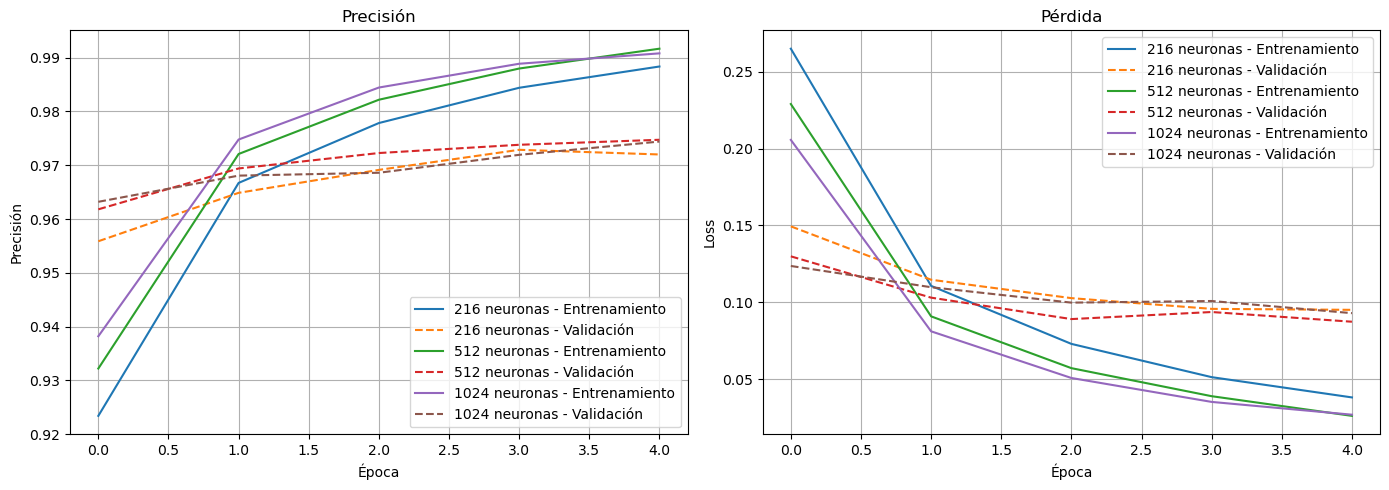


Entrenando modelo con 216 neuronas...
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9260 - loss: 0.2603 - val_accuracy: 0.9549 - val_loss: 0.1520
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9684 - loss: 0.1089 - val_accuracy: 0.9673 - val_loss: 0.1094
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9778 - loss: 0.0721 - val_accuracy: 0.9706 - val_loss: 0.0977
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9845 - loss: 0.0517 - val_accuracy: 0.9709 - val_loss: 0.0961
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9887 - loss: 0.0372 - val_accuracy: 0.9735 - val_loss: 0.0915
→ Tiempo de entrenamiento: 27.11 segundos

Entrenando modelo con 512 neuronas...
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9330 - loss: 0.2274 - val_accuracy: 0.9636 - val_loss: 0.1250
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9728 - loss: 0.0905 - val_accuracy: 0.9

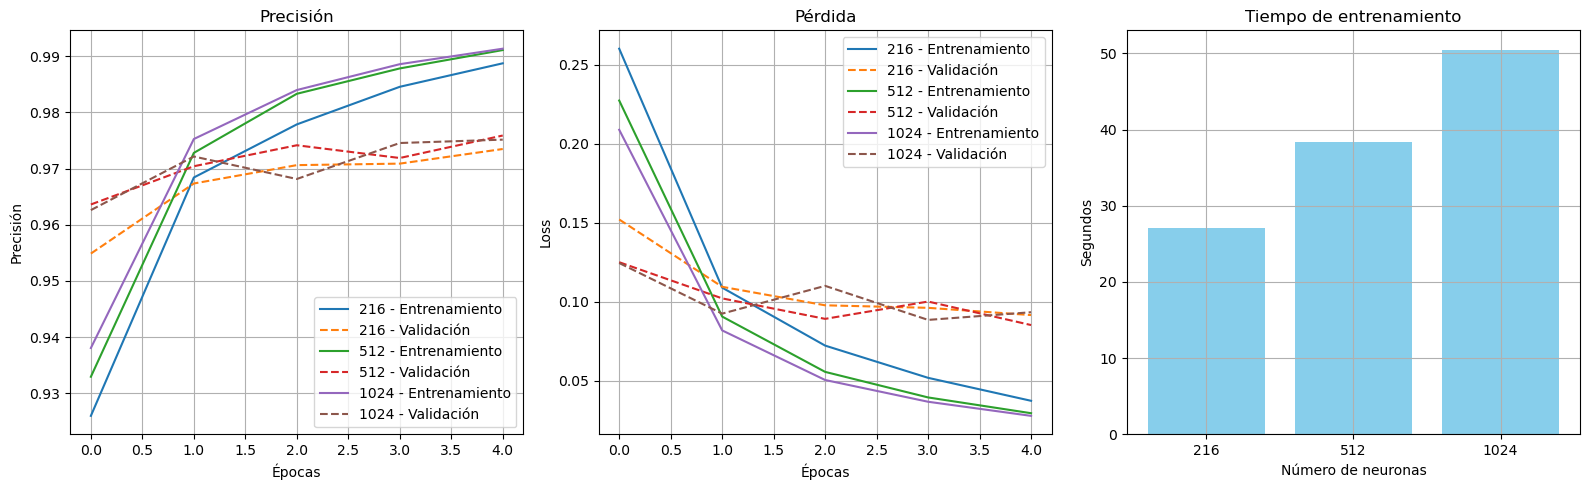

In [20]:
import matplotlib.pyplot as plt

# Función para graficar accuracy y val_accuracy de varios histories
def plot_histories(histories, labels):
    plt.figure(figsize=(14, 5))

    # Precisión
    plt.subplot(1, 2, 1)
    for history, label in zip(histories, labels):
        plt.plot(history.history['accuracy'], label=f'{label} - Entrenamiento')
        plt.plot(history.history['val_accuracy'], linestyle='--', label=f'{label} - Validación')
    plt.title('Precisión')
    plt.xlabel('Época')
    plt.ylabel('Precisión')
    plt.legend()
    plt.grid(True)

    # Pérdida
    plt.subplot(1, 2, 2)
    for history, label in zip(histories, labels):
        plt.plot(history.history['loss'], label=f'{label} - Entrenamiento')
        plt.plot(history.history['val_loss'], linestyle='--', label=f'{label} - Validación')
    plt.title('Pérdida')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Llamada a la función con tus histories
plot_histories(
    [history_216, history_512, history_1024],
    ['216 neuronas', '512 neuronas', '1024 neuronas']
)

import time
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

def crear_modelo(num_neuronas):
    model = Sequential([
        Input(shape=(784,)),
        Dense(num_neuronas, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    return model

# --- Entrenamiento con diferentes tamaños ---
neuronas_lista = [216, 512, 1024]
resultados = {}

for n in neuronas_lista:
    print(f"\nEntrenando modelo con {n} neuronas...")
    model = crear_modelo(n)

    start = time.time()
    history = model.fit(
        training_images, training_labels,
        epochs=5,
        batch_size=32,
        validation_split=0.25,
        verbose=1
    )
    end = time.time()

    resultados[n] = {
        "history": history,
        "tiempo": end - start
    }
    print(f"→ Tiempo de entrenamiento: {end - start:.2f} segundos")

# --- Gráficas ---
plt.figure(figsize=(16, 5))

# Precisión
plt.subplot(1, 3, 1)
for n in neuronas_lista:
    plt.plot(resultados[n]["history"].history["accuracy"], label=f'{n} - Entrenamiento')
    plt.plot(resultados[n]["history"].history["val_accuracy"], '--', label=f'{n} - Validación')
plt.title("Precisión")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)

# Pérdida
plt.subplot(1, 3, 2)
for n in neuronas_lista:
    plt.plot(resultados[n]["history"].history["loss"], label=f'{n} - Entrenamiento')
    plt.plot(resultados[n]["history"].history["val_loss"], '--', label=f'{n} - Validación')
plt.title("Pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Tiempo
plt.subplot(1, 3, 3)
tiempos = [resultados[n]["tiempo"] for n in neuronas_lista]
plt.bar([str(n) for n in neuronas_lista], tiempos, color="skyblue")
plt.title("Tiempo de entrenamiento")
plt.xlabel("Número de neuronas")
plt.ylabel("Segundos")
plt.grid(True)

plt.tight_layout()
plt.show()

Respuesta a la pregunta 5.1:

Como podemos ver, si nos fijamos en los valores de entrenamiento, cuanto más neuronas tiene, más capacidad tiene de aprender rápido: antes alcanzamos una alta precisión. 
Es curioso como ver, que esto es principalmente para el entrenamiento, para la validación, es díficil sacar conclusiones, puesto que va "bailando" según las épocas (probablemente debido a un ligero sobreajuste).

Respecto a las pérdidas, vemos que también disminuye cuantas mas neuronas tiene. Sin embargo, nos ocurre parecido al caso de la precisión: esto no se refleja en la validación (que incluso empeora en la época 5 con 1024 neuronas). Esto nos puede indicar saturación de la capacidad.

Respecto al tiempo de entrenamiento, vemos que aumenta significativamente con el númeri de neuronas (lógico).

Vemos por tanto que no siempre más es mejor.

# 6: Número de neuronas de la capa de salida
Considerad la capa final, la de salida de la red neuronal de la pregunta 3.

**Pregunta 6.1**: ¿Por qué son 10 las neuronas de la última capa?

**Pregunta 6.2**: ¿Qué pasaría si tuvieras una cantidad diferente a 10?

Por ejemplo, intenta entrenar la red con 5, para ello utiliza la red neuronal de la pregunta 1 y cambia a 5 el número de neuronas en la última capa.

In [ ]:
"""model_5 = Sequential([
    Input(shape=(784,)),
    Dense(512, activation='relu'),
    Dense(5, activation='softmax')  # Capa de salida con 5 neuronas
])
model_5.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
history_5 = model_5.fit(
    training_images, training_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.25
)
"""

#Lo pongo en comentario porque no se puede ejecutar.

"model_5 = Sequential([\n    Input(shape=(784,)),\n    Dense(512, activation='relu'),\n    Dense(5, activation='softmax')  # Capa de salida con 5 neuronas\n])\nmodel_5.compile(\n    loss='categorical_crossentropy',\n    optimizer='adam',\n    metrics=['accuracy']\n)\nhistory_5 = model_5.fit(\n    training_images, training_labels,\n    epochs=5,\n    batch_size=32,\n    validation_split=0.25\n)\n"

Respuesta a la pregunta 6.1:

Porque el conjunto de datos que estamos clasificando es MNIST, que contiene imágenes de dígitos escritos a mano de 0 a 9. (10 clases).

Cada neurona de salida representa la probabilidad de que la imagen pertenezca a una u a otra clase.

Esto se logra con una activación de softmax que convierte las salidas en una distribución de probabilidad de suma 1.

Respuesta a la pregunta 6.2:

Como vemos, nos ha salido un error. Esto es porque la red, al poner 5 neuronas de salida solo puede elegir entre 5 clases, de las 10 posibles.

El modelo está intentado predecir solo 5 clases, mientras que las etiquetas están codificadas como vectores one-hot de 10 posiciones, lo cual genera un conflicto de formas (shapes).

# 7: Aumento de epoch y su efecto en la red neuronal
En este ejercicio vamos a ver el impacto de aumentar los epoch en el entrenamiento. Usando la red neuronal de la pregunta 3:

**Pregunta 7.1**
* Intentad 15 epoch para su entrenamiento, probablemente obtendras un modelo con una pérdida mucho mejor que el que tiene 5.

**Pregunta 7.2**
* Intenta ahora con 30 epoch para su entrenamiento.

**Pregunta 7.3**
* ¿Qué está pasando en la pregunta anterior? Explica tu respuesta y da el nombre de este efecto si lo conoces.

In [ ]:
model_15 = Sequential([
    Input(shape=(784,)),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')  # 10 salidas para MNIST
])

model_15.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_15 = model_15.fit(
    training_images, training_labels,
    epochs=15,
    batch_size=32,
    validation_split=0.25
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9334 - loss: 0.2264 - val_accuracy: 0.9595 - val_loss: 0.1329
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9736 - loss: 0.0862 - val_accuracy: 0.9705 - val_loss: 0.1005
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9829 - loss: 0.0558 - val_accuracy: 0.9705 - val_loss: 0.0935
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9879 - loss: 0.0388 - val_accuracy: 0.9730 - val_loss: 0.0902
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9910 - loss: 0.0282 - val_accuracy: 0.9763 - val_loss: 0.0840
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9939 - loss: 0.0199 - val_accuracy: 0.9767 - val_loss: 0.0857
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9946 - loss: 0.0177 - val_accuracy: 0.9663 - val_loss: 0.1425
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9948 - loss: 0.0159 -

In [ ]:
model_30 = Sequential([
    Input(shape=(784,)),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

model_30.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_30 = model_30.fit(
    training_images, training_labels,
    epochs=30,
    batch_size=32,
    validation_split=0.25
)


Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9329 - loss: 0.2291 - val_accuracy: 0.9619 - val_loss: 0.1258
Epoch 2/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9723 - loss: 0.0905 - val_accuracy: 0.9692 - val_loss: 0.1005
Epoch 3/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9824 - loss: 0.0554 - val_accuracy: 0.9728 - val_loss: 0.0938
Epoch 4/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9871 - loss: 0.0404 - val_accuracy: 0.9753 - val_loss: 0.0871
Epoch 5/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9902 - loss: 0.0301 - val_accuracy: 0.9747 - val_loss: 0.0887
Epoch 6/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9928 - loss: 0.0223 - val_accuracy: 0.9743 - val_loss: 0.0955
Epoch 7/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9946 - loss: 0.0166 - val_accuracy: 0.9759 - val_loss: 0.0910
Epoch 8/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9964 - loss: 0.

Respuesta a la pregunta 7.3:

Vemos que cuantas más épocas, más aumenta la precisión del entrenamiento. 

Sin embargo, la precisión de la validación se estanca. Al final, incluso la pérdida de la validación aumenta.

Es decir, el modelo empieza a tener overfitting, ajustándose mucho a los valores de entrenamiento, pero empezando a dar peores resultados fuera de dicho entrenamiento.

# 8: Early stop
En el ejercicio anterior, cuando entrenabas con epoch extras, tenías un problema en el que tu pérdida podía cambiar. Puede que te haya llevado un poco de tiempo esperar a que el entrenamiento lo hiciera,  y puede que hayas pensado "¿no estaría bien si pudiera parar el entrenamiento cuando alcance un valor deseado?", es decir, una precisión del 85% podría ser suficiente para ti, y si alcanzas eso después de 3 epoch, ¿por qué sentarte a esperar a que termine muchas más épocas? Como cualquier otro programa existen formas de parar la ejecución

A partir del código de ejemplo, hacer una nueva función que tenga en cuenta la perdida (loss) y que pueda parar el código para evitar que ocurra el efeto secundario que vimos en el ejercicio 5.

In [ ]:
class myCallback(tf.keras.callbacks.Callback):
      def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy')> 0.85):
              print("\nAlcanzado el 85% de precisión, se cancela el entrenamiento!!")
              self.model.stop_training = True

**Pregunta 8.1.**: Consulta la documentación de Keras y aprende cómo podemos utilizar Early stop en nuestro modelos.

In [ ]:
# Callback personalizado
class myLossCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('loss') < 0.2:
            print(f"\n Pérdida por debajo de 0.2 en la época {epoch+1}, se detiene el entrenamiento.")
            self.model.stop_training = True

# Crear el modelo
model_es = Sequential([
    Input(shape=(784,)),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
])

model_es.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Entrenar el modelo con early stopping
callback = myLossCallback()

history_es = model_es.fit(
    training_images, training_labels,
    epochs=30,
    batch_size=32,
    validation_split=0.25,
    callbacks=[callback]
)

Epoch 1/30
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9338 - loss: 0.2295 - val_accuracy: 0.9644 - val_loss: 0.1227
Epoch 2/30
1401/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9730 - loss: 0.0922
 Pérdida por debajo de 0.2 en la época 2, se detiene el entrenamiento.
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9731 - loss: 0.0900 - val_accuracy: 0.9666 - val_loss: 0.1120


## 9. Unidades de activación

En este ejercicio, vamos a evaluar la importancia de utilizar las unidades de activación adecuadas. Como hemos visto en clase, funciones de activación como sigmoid han dejado de utilizarse en favor de otras unidades como ReLU.

**Pregunta 9.1**: Utilizando la red realizada en el ejercicio 3, escribir un breve análisis comparando la utilización de unidades sigmoid y ReLU (por ejemplo, se pueden comentar aspectos como velocidad de convergencia, métricas obtenidas...). Explicar por qué pueden darse estas diferencias. Opcionalmente, comparar con otras activaciones disponibles en Keras.

*Pista: Usando redes más grandes se hace más sencillo apreciar las diferencias. Es mejor utilizar al menos 3 o 4 capas densas.*

In [ ]:
# Función para crear el modelo con activación dada
def build_model(activation):
    model = Sequential([
        Input(shape=(784,)),
        Dense(512, activation=activation),
        Dense(256, activation=activation),
        Dense(128, activation=activation),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# --------------------------------------------
# Función para entrenar y capturar historia + gradientes
def train_and_record_gradients(activation, epochs=5):
    model = build_model(activation)
    optimizer = tf.keras.optimizers.Adam()
    loss_fn = tf.keras.losses.CategoricalCrossentropy()

    train_acc = []
    val_acc = []
    train_loss = []
    val_loss = []
    gradient_norms = []

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs} | Activación: {activation}")

        grads_epoch = []

        # Entrenamiento manual para extraer gradientes
        for i in range(0, len(training_images), 32):
            x_batch = training_images[i:i+32]
            y_batch = training_labels[i:i+32]

            with tf.GradientTape() as tape:
                preds = model(x_batch, training=True)
                loss = loss_fn(y_batch, preds)

            grads = tape.gradient(loss, model.trainable_weights)
            grads_epoch.append(np.mean([tf.norm(g).numpy() for g in grads if g is not None]))

            optimizer.apply_gradients(zip(grads, model.trainable_weights))

        # Evaluación por época
        train_metrics = model.evaluate(training_images, training_labels, verbose=0)
        val_metrics = model.evaluate(test_images, test_labels, verbose=0)

        train_loss.append(train_metrics[0])
        train_acc.append(train_metrics[1])
        val_loss.append(val_metrics[0])
        val_acc.append(val_metrics[1])
        gradient_norms.append(np.mean(grads_epoch))

    return {
        'activation': activation,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'gradient_norms': gradient_norms
    }

# --------------------------------------------
# Entrenamiento y comparación de activaciones
activations = ['relu', 'sigmoid', 'tanh', 'selu']
results = []

for act in activations:
    print(f"\n--- Entrenando modelo con activación '{act}' ---")
    start_time = time.time()

    res = train_and_record_gradients(act)

    end_time = time.time()
    total_time = end_time - start_time

    res['training_time'] = total_time
    print(f"Tiempo total para '{act}': {total_time:.2f} segundos")

    results.append(res)



--- Entrenando modelo con activación 'relu' ---
Epoch 1/5 | Activación: relu
Epoch 2/5 | Activación: relu
Epoch 3/5 | Activación: relu
Epoch 4/5 | Activación: relu
Epoch 5/5 | Activación: relu
Tiempo total para 'relu': 616.02 segundos

--- Entrenando modelo con activación 'sigmoid' ---
Epoch 1/5 | Activación: sigmoid
Epoch 2/5 | Activación: sigmoid
Epoch 3/5 | Activación: sigmoid
Epoch 4/5 | Activación: sigmoid
Epoch 5/5 | Activación: sigmoid
Tiempo total para 'sigmoid': 694.07 segundos

--- Entrenando modelo con activación 'tanh' ---
Epoch 1/5 | Activación: tanh
Epoch 2/5 | Activación: tanh
Epoch 3/5 | Activación: tanh
Epoch 4/5 | Activación: tanh
Epoch 5/5 | Activación: tanh
Tiempo total para 'tanh': 679.39 segundos

--- Entrenando modelo con activación 'selu' ---
Epoch 1/5 | Activación: selu
Epoch 2/5 | Activación: selu
Epoch 3/5 | Activación: selu
Epoch 4/5 | Activación: selu
Epoch 5/5 | Activación: selu
Tiempo total para 'selu': 479.27 segundos


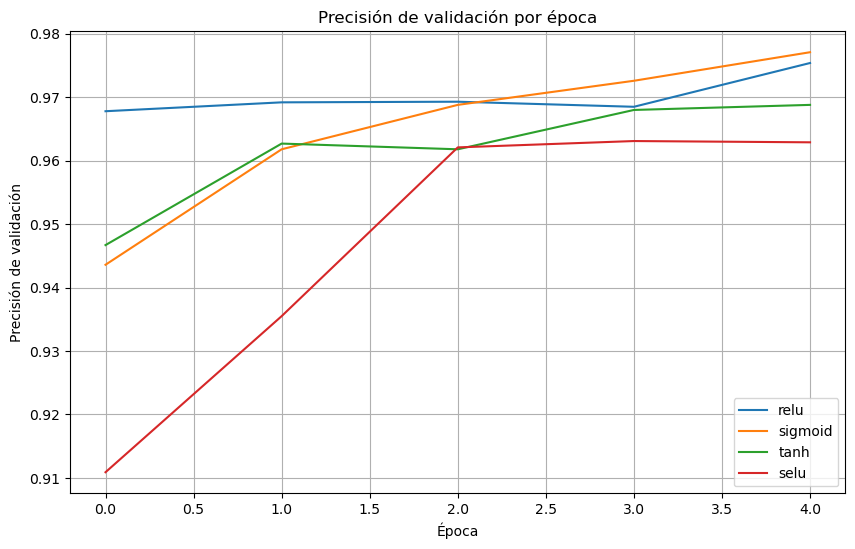

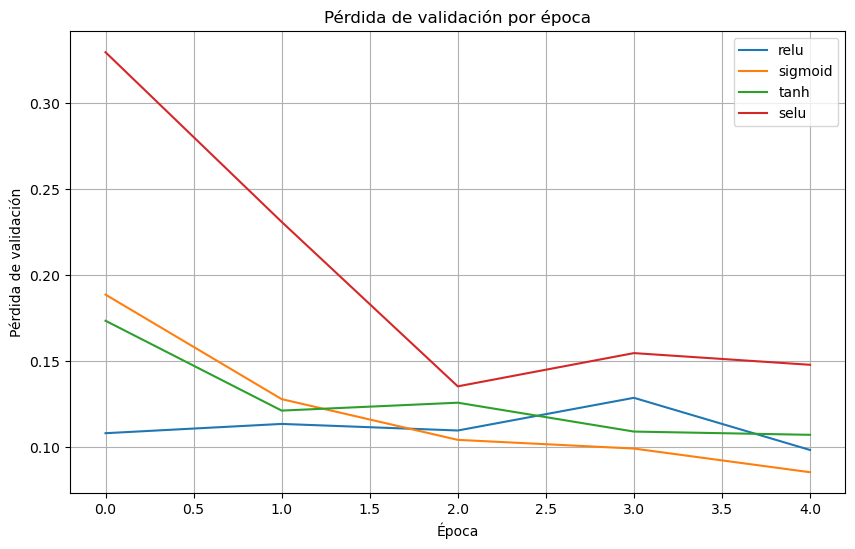

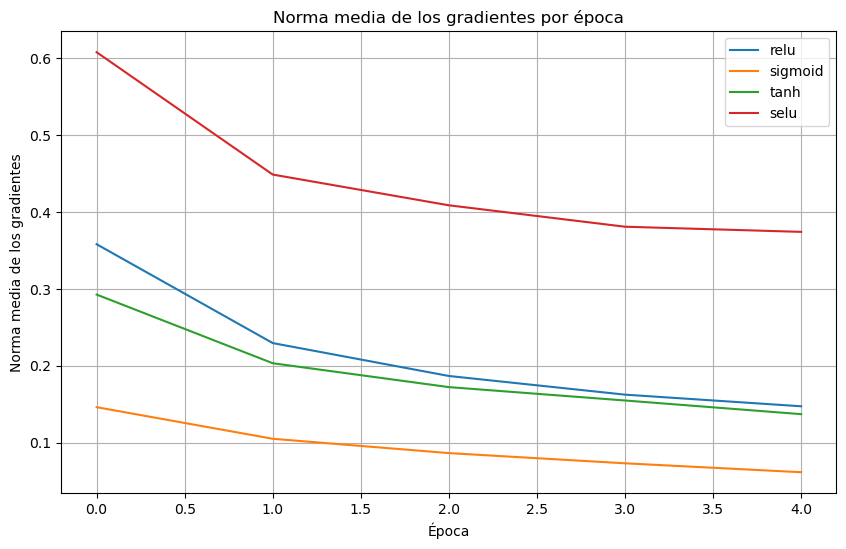

c:\Users\cgiral\AppData\Local\miniconda3\envs\github-portfolio\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


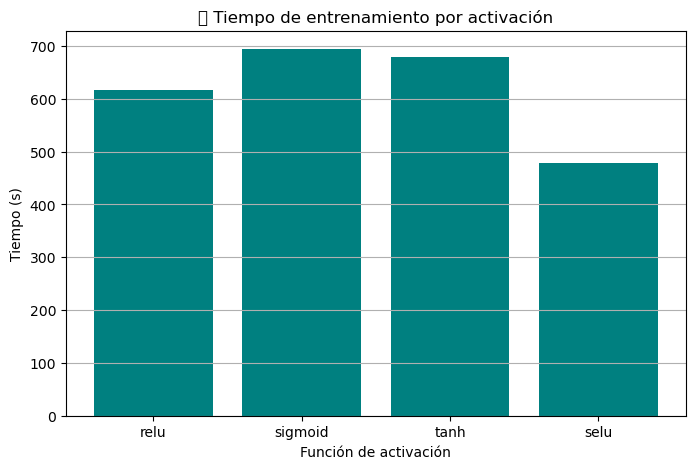

In [27]:
# Visualización
def plot_metric(metric_name, ylabel):
    plt.figure(figsize=(10, 6))
    for res in results:
        plt.plot(res[metric_name], label=res['activation'])
    plt.title(ylabel + ' por época')
    plt.xlabel('Época')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metric('val_acc', 'Precisión de validación')
plot_metric('val_loss', 'Pérdida de validación')
plot_metric('gradient_norms', 'Norma media de los gradientes')

# Gráfico de barras comparando los tiempos de entrenamiento
plt.figure(figsize=(8, 5))
activs = [res['activation'] for res in results]
times = [res['training_time'] for res in results]

plt.bar(activs, times, color='teal')
plt.title("⏱️ Tiempo de entrenamiento por activación")
plt.xlabel("Función de activación")
plt.ylabel("Tiempo (s)")
plt.grid(True, axis='y')
plt.show()

Vemos que ReLu obtiene mejores resultados globales en cuanto a precisión, sobre todo en cuanto al tiempo que tarde en alcanzar una precisión alta. (En la quinta época todas tienen una buena precisión).
En su contraparte, Selu es la que comienza con peores resultados, aunque como digo, todas acaban teniendo buenos resultados en la quinta época.

También hemos visto que el tiempo de computación ha sido similar para todas.

Respecto al gradiente, vemos que sigmoid tiene el gradiente más pequeño, lo que implica que las activaciones de sigmoid tienden a saturarse antes. Por contraparte, Selu tiene el mayor gradiente, por lo que tarda más en converger.

En cuanto a la pérdida de validación, sigmoid es el que mejor resultados tiene, y Selu el que peor.

Igualmente, para este caso en concreto cualquiera de las activaciones podría resultar correcta, no tiene ninguna malos resultados.

## 10. Inicialización de parámetros

En este ejercicio, vamos a evaluar la importancia de una correcta inicialización de parámetros en una red neuronal.

**Pregunta 10.1**: Partiendo de una red similar a la del ejercicio anterior (usando ya ReLUs), comentar las diferencias que se aprecian en el entrenamiento al utilizar distintas estrategias de inicialización de parámetros. Para ello, inicializar todas las capas con las siguientes estrategias, disponibles en Keras, y analizar sus diferencias:

* Inicialización con ceros.
* Inicialización con una variable aleatoria normal.
* Inicialización con los valores por defecto de Keras para una capa Dense (estrategia *glorot uniform*)

In [28]:
from tensorflow.keras.initializers import Zeros, RandomNormal, GlorotUniform

#Voy a usar varias capas densas como en el anterior ejercicio, para ver mejor la importancia en la inicialización de los parámetros.
# Función para construir un modelo con la inicialización deseada
def build_model_with_initializer(initializer):
    model = Sequential([
        Input(shape=(784,)),
        Dense(512, activation='relu', kernel_initializer=initializer),
        Dense(256, activation='relu', kernel_initializer=initializer),
        Dense(128, activation='relu', kernel_initializer=initializer),
        Dense(10, activation='softmax', kernel_initializer=initializer)
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Entrenamiento y cálculo de gradiente medio
def train_and_evaluate(initializer, name):
    model = build_model_with_initializer(initializer)
    start = time.time()
    history = model.fit(training_images, training_labels, epochs=5, batch_size=32,
                        validation_data=(test_images, test_labels), verbose=0)
    end = time.time()
    
    # Cálculo del gradiente medio
    weights = model.trainable_weights
    with tf.GradientTape() as tape:
        y_pred = model(training_images[:100])  # Solo un batch para evaluar
        loss = tf.keras.losses.categorical_crossentropy(training_labels[:100], y_pred)
    gradients = tape.gradient(loss, weights)
    grad_norms = [tf.reduce_mean(tf.abs(g)).numpy() for g in gradients if g is not None]
    avg_gradient = np.mean(grad_norms)

    return {
        "name": name,
        "history": history,
        "time": end - start,
        "avg_gradient": avg_gradient
    }


initializers = {
    "zeros": Zeros(),
    "random_normal": RandomNormal(mean=0.0, stddev=0.05),
    "glorot_uniform": GlorotUniform()
}

results_init = []

for name, init in initializers.items():
    print(f"\nEntrenando modelo con inicialización: {name}")
    result = train_and_evaluate(init, name)
    results_init.append(result)


Entrenando modelo con inicialización: zeros

Entrenando modelo con inicialización: random_normal

Entrenando modelo con inicialización: glorot_uniform


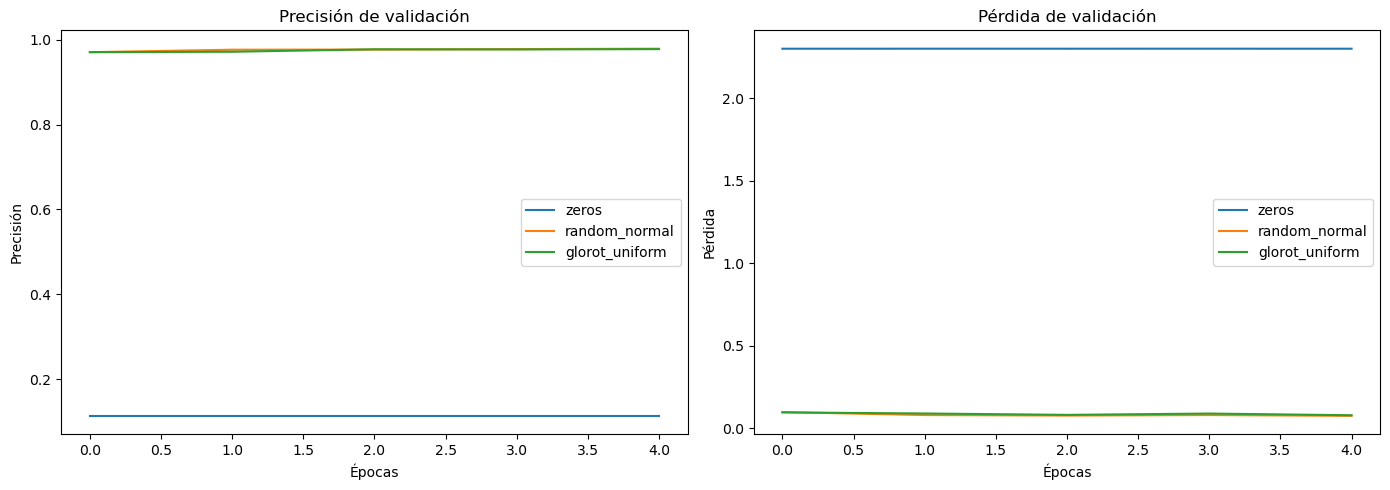

zeros: tiempo = 44.85s, gradiente medio = 0.254460
random_normal: tiempo = 56.43s, gradiente medio = 0.053693
glorot_uniform: tiempo = 58.17s, gradiente medio = 0.109134


In [29]:
# Gráficas
plt.figure(figsize=(14, 5))

# Precisión
plt.subplot(1, 2, 1)
for res in results_init:
    plt.plot(res["history"].history['val_accuracy'], label=f'{res["name"]}')
plt.title("Precisión de validación")
plt.xlabel("Épocas")
plt.ylabel("Precisión")
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
for res in results_init:
    plt.plot(res["history"].history['val_loss'], label=f'{res["name"]}')
plt.title("Pérdida de validación")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()

plt.tight_layout()
plt.show()

# Gradiente medio y tiempos
for res in results_init:
    print(f"{res['name']}: tiempo = {res['time']:.2f}s, gradiente medio = {res['avg_gradient']:.6f}")

Vemos que se podría utilizar random_normal o glorot_uniform (este ligeramente superior).
Sin embargo, iniciando con ceros no se llega nunca a entrenar correctamente el modelo. 

La inicialización con ceros es problemática porque impone una simetría completa entre las neuronas: todos los pesos empiezan idénticos, de modo que todas
las neuronas de una capa calculan la misma función y reciben las mismas actualizaciones en cada paso.
En particular para ReLU esto provoca que tanto las salidas como los gradientes sean cero desde el inicio, cortocircuitando el aprendizaje. 
La precisión queda al azar y no mejora con el entrenamiento.

La inicialización con GlorotUniform está diseñada para "romper" la simetría y mantener la varianza de las activaciones constante a lo largo de la red.
Al escalar los pesos inciales según el tamaño de las capas, GlorotUniform evita que los gradientes se atenúen drásticamente o exploten en redes profundas.
Esto se traduce en gradientes medios más altos y bien equilibrados durante el entrenamiento, permitiendo actualizaciones efectivas de pesos. Como resultado, GlorotUniform produce un aprendizaje más rápido y estable (mejor rendimiento final) que una inicialización aleatoria normal con escala fija, y muchísimo mejor que ceros.

## 11. Optimizadores

**Problema 11.1**: Partiendo de una red similar a la del ejercicio anterior (utilizando la mejor estrategia de inicialización observada), comparar y analizar las diferencias que se observan  al entrenar con varios de los optimizadores vistos en clase, incluyendo SGD como optimizador básico (se puede explorar el espacio de hiperparámetros de cada optimizador, aunque para optimizadores más avanzados del estilo de RMSprop es buena idea dejar los valores por defecto provistos por Keras).

In [30]:
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
#No hace falta especificar la inicialización de los parámetros, ya que por defecto se usa GlorotUniform.

def build_model_with_optimizer(optimizer):
    model = Sequential([
        Input(shape=(784,)),
        Dense(512, activation='relu', kernel_initializer=GlorotUniform()),
        Dense(256, activation='relu', kernel_initializer=GlorotUniform()),
        Dense(128, activation='relu', kernel_initializer=GlorotUniform()),
        Dense(10, activation='softmax', kernel_initializer=GlorotUniform())
    ])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def train_and_evaluate_optimizer(optimizer, name):
    model = build_model_with_optimizer(optimizer)
    start = time.time()
    history = model.fit(training_images, training_labels, epochs=5, batch_size=32,
                        validation_data=(test_images, test_labels), verbose=0)
    end = time.time()

    final_accuracy = history.history['val_accuracy'][-1]
    final_loss = history.history['val_loss'][-1]

    return {
        "name": name,
        "history": history,
        "time": end - start,
        "val_accuracy": final_accuracy,
        "val_loss": final_loss
    }

optimizers = {
    "SGD": SGD(),
    "SGD_momentum": SGD(momentum=0.9),
    "RMSprop": RMSprop(),
    "Adam": Adam()
}

results_opt = []

for name, opt in optimizers.items():
    print(f"\nEntrenando con optimizador: {name}")
    result = train_and_evaluate_optimizer(opt, name)
    results_opt.append(result)


Entrenando con optimizador: SGD

Entrenando con optimizador: SGD_momentum

Entrenando con optimizador: RMSprop

Entrenando con optimizador: Adam


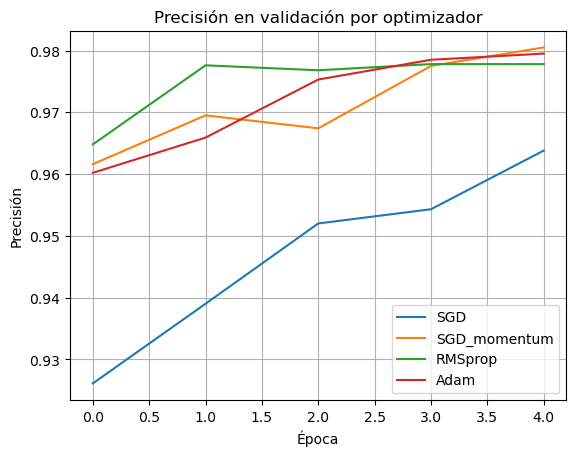

In [31]:
for result in results_opt:
    plt.plot(result["history"].history['val_accuracy'], label=result["name"])

plt.title("Precisión en validación por optimizador")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.legend()
plt.grid(True)
plt.show()

Vemos que Adam y RMSprop son los que más rápido convergenm seguidos de SGD con momentum, que tarda algo más en converger pero da similares resultados.
Sin embargo, SGD si tarda aún más en converger y no llega a tener tanta precisión (al menos para las épocas entrenado).

## 12. Regularización y red final

**Problema 12.1**: Entrenar una red final que sea capaz de obtener una accuracy en el validation superior al 95%. Para ello, combinar todo lo aprendido anteriormente y utilizar técnicas de regularización para evitar overfitting. Algunos de los elementos que pueden tenerse en cuenta son los siguientes.

* Número de capas y neuronas por capa
* Optimizadores y sus parámetros
* Batch size
* Unidades de activación
* Uso de capas dropout, regularización L2, regularización L1...
* Early stopping (se puede aplicar como un callback de Keras, o se puede ver un poco "a ojo" cuándo el modelo empieza a caer en overfitting y seleccionar el número de epochs necesarias)
* Batch normalization

Si los modelos entrenados anteriormente ya se acercaban al valor requerido de accuracy, probar distintas estrategias igualmente y comentar los resultados.

Explicar brevemente la estrategia seguida y los modelos probados para obtener el modelo final, que debe verse entrenado en este Notebook. No es necesario guardar el entrenamiento de todos los modelos que se han probado, es suficiente con explicar cómo se ha llegado al modelo final.

In [32]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dropout

# Callback de early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Construcción del modelo
model = Sequential([
    Dense(256, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=l2(0.001), input_shape=(training_images.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu', kernel_initializer=HeNormal(), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(10, activation='softmax')  # 10 clases
])

# Compilación
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamiento
history = model.fit(training_images, training_labels,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=64,
                    callbacks=[early_stopping],
                    verbose=1)

# Evaluación final
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

c:\Users\cgiral\AppData\Local\miniconda3\envs\github-portfolio\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8505 - loss: 1.1102 - val_accuracy: 0.9484 - val_loss: 0.6557
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9295 - loss: 0.6347 - val_accuracy: 0.9607 - val_loss: 0.4577
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9396 - loss: 0.4821 - val_accuracy: 0.9630 - val_loss: 0.3640
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9446 - loss: 0.4040 - val_accuracy: 0.9599 - val_loss: 0.3317
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9462 - loss: 0.3679 - val_accuracy: 0.9643 - val_loss: 0.2981
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9505 - loss: 0.3403 - val_accuracy: 0.9682 - val_loss: 0.2700
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9490 - loss: 0.3321 - val_accuracy: 0.9678 - val_loss: 0.2701
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9507 - loss: 0.3174 - val_accu

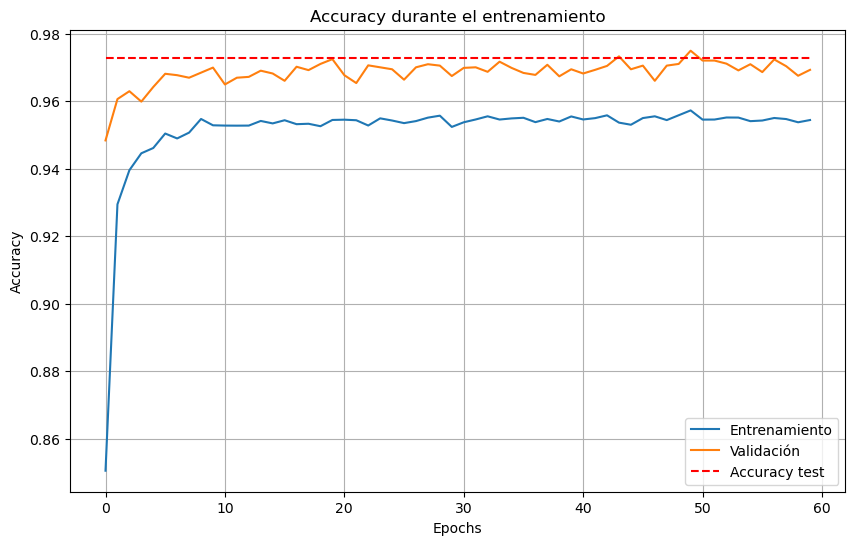

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.hlines(test_acc, 0, len(history.history['accuracy'])-1, 
           colors='red', linestyles='dashed', label='Accuracy test')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


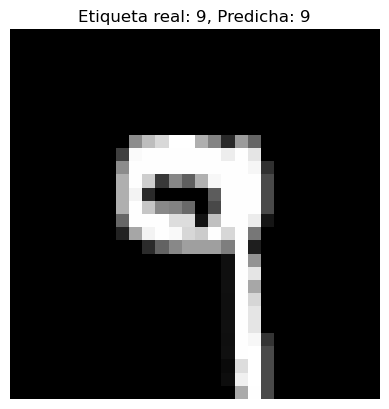

In [35]:
import random
index = random.randint(0, len(test_images)-1)

plt.imshow(test_images[index].reshape(28,28), cmap='gray')  # Ajusta si no es MNIST
plt.title(f"Etiqueta real: {np.argmax(test_labels[index])}, Predicha: {predicted_labels[index]}")
plt.axis('off')
plt.show()

### Estrategia para alcanzar >95% de accuracy en validación

Para obtener un modelo robusto y evitar el overfitting, he probado distintas arquitecturas y técnicas vistas durante el curso. Finalmente, me he decantado por una red profunda con:

- Varias capas densas (256 → 128 → 64), activación ReLU
- Inicializador `HeNormal`, óptimo para ReLU
- Regularización **L2** y **Dropout** (0.3) en todas las capas ocultas.
    - Cogemos L2, ya que penaliza los pesos grandes suavemente. Empuja los pesos a ser pequeños pero no exactamente 0.
    - Sin embargo L1 fuerza a que muchos pesos sean 0 --> sparsity (modelos más simples).
    - Dropout = 0.3 --> Significa que el 30% de las neuronas se apagan en cada paso de entrenamiento.
- Normalización por **BatchNormalization** tras cada capa
    - Con BatchNormalization normalizamos las salidas de cada capa antes de pasar a la capa siguiente. Esto permite acelerar el entrenamiento, hacer más estable la red y evitar que la activación de una capa cambie demasiado durante el entrenamiento. Se hace justo después de una capa densa y antes del dropout de la siguiente capa.
- Optimizador `Adam` con `learning_rate=0.001`
- Callback `EarlyStopping` con paciencia de 10 epochs
    - monitor:'val_loss': observa la pérdida de error.
    - patience: 10. Espera 10 épocas sin mejora antes de parar.
    - restore_best_weights: cuando se para, recupera los pesos que dieron la mejor validación.
- Epochs máximos: 100, batch size: 64

El modelo supera el 95% de accuracy en validación y mantiene un buen rendimiento en test.